# MS Detection with EEG and Machine Learning

**Authors:** Karam Akil, Muwaffak Abed

## Project Overview

In this notebook, we will use machine learning to predict MS using preprocessed EEG data:
1. We will analyze the data and handle any outliers and clean the data.
2. We will train machine learning models on the data (LDA classifier, svm, Random forest, Logistic regressor).
3. We will test them and analyze the results.

## 1. Imports

In [22]:
# 1.1 Data Manipulation
import pandas as pd
import numpy as np

# 1.2 The Validation Method (Crucial for your "Row per Epoch" strategy)
from sklearn.model_selection import LeaveOneGroupOut

# 1.3 Preprocessing (Important for SVM and kNN)
from sklearn.preprocessing import StandardScaler

# 1.4 The Models (Classifiers)
# The ones from the study:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis  # LDA
from sklearn.svm import SVC                                         # SVM
from sklearn.tree import DecisionTreeClassifier                     # CART (Decision Tree)
from sklearn.neighbors import KNeighborsClassifier                  # kNN

# 1.5 The recommended additions for stability:
from sklearn.ensemble import RandomForestClassifier                 # Random Forest
from sklearn.linear_model import LogisticRegression                 # Logistic Regression

# 1.6 Metrics (To measure success)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)

# 1.7 Visualization (Optional, for plotting Confusion Matrices)
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading & Quality Control

* We load the CSV and remove the artifact we found.
* Channel CP2 is problematic since in Subject H_1 it has a very big value.
* Therefore, we found that dropping the channel completely is the most approperiate so our models dont get skewed.

In [23]:
# 2.1: Load The data and show it
df = pd.read_csv('FINAL_DATASET_WINDOWED_FULL.csv')
print(f"Original shape: {df.shape}")
print(f'Original data: {df.describe()}')


# 2.2: Drop the Bad channel and Show the Cleaned Data
# Drop artifacts
cols_to_drop = [c for c in df.columns if 'CP2' in c]
df = df.drop(columns=cols_to_drop)
print(f"Cleaned shape: {df.shape}")
print(f'Cleaned data: {df.describe()}')

Original shape: (589, 623)
Original data:             Label  Window_Index  Fp1_abs_delta  Fp1_abs_theta  Fp1_abs_alpha  \
count  589.000000    589.000000     589.000000     589.000000     589.000000   
mean     0.505942     28.998302     805.721090      80.845265      15.611206   
std      0.500390     17.093232     807.428542      79.028140      12.050500   
min      0.000000      0.000000       6.188561       2.281867       1.910662   
25%      0.000000     14.000000     173.503834      17.080720       6.386066   
50%      1.000000     29.000000     591.412317      58.788094      11.866002   
75%      1.000000     44.000000    1144.955582     121.656866      21.634309   
max      1.000000     60.000000    4270.137731     416.567606      69.305404   

       Fp1_abs_beta  Fp1_abs_gamma  Fp1_rel_delta  Fp1_rel_theta  \
count    589.000000     589.000000     589.000000     589.000000   
mean       7.401213       4.945297       0.808518       0.106103   
std        4.913089       3.91094

## 3. Methodology Explanation

## 4. Model Configuration and Data Feature , Target, Group Definition


* We will load our models for training and testing.
* We will use a dictionary to store our models as it is the cleanest way for
* We will also define the Features, target, and Groups for training

In [24]:
# 4.1: Storing the models in a dictionary for use in the training, validation loop
models = {
    "LDA": LinearDiscriminantAnalysis(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='linear', random_state=42),
    "kNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
}


# 4.2: Define Features (X), target (y), and Groups (Subject_ID)
X = df.drop(['Subject_ID', 'Label', 'Window_Index'], axis=1)
y = df['Label']
groups = df['Subject_ID']
print(f"Total Subjects: {groups.nunique()}")

Total Subjects: 10


## 5. The training and Validation Loop

* For training and Validation we will use the LeaveOneGroupOut method
* Since we our dataset has only 1 subjects, we opted for epoch based rows instead of subject based
* We will train the model on the remaining Groups (subjects) and then test it on one subject
* We will normalize the data using StandardScaler
* for evaluation we will test accuracy, sensitivity, and specificity

In [25]:
# 5.1: Store results
results_data = []
best_model_name = "Random Forest" # We will save predictions for this one to plot later
best_model_preds = []
best_model_truth = []

# 4.2: Initialize the training and Validation loop
print(f"{'Model Name':<25} | {'Subject Accuracy':<15} | {'Sensitivity':<15} | {'Specificity':<15} | {'Precision':<15}")
print("-" * 100)
for name, model in models.items():
    # Initialize the LeaveOneGroupOut method
    logo = LeaveOneGroupOut()

    # Initialize subje
    subject_accuracies = []
    subject_truths = []
    subject_preds = []

    # Split by subject:
    for train_idx, test_idx in logo.split(X,y,groups=groups):
        X_train,X_test= X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Lets normalize our data (by Using StandardScaler) to avoid bias in SVM and kNN
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Train the model
        model.fit(X_train, y_train)

        # Predict on all windows of the Test Subject
        window_predictions = model.predict(X_test)

        # --- VOTING MECHANISM ---
        # If > 30% of windows are MS (1), the Subject is MS.
        ms_window_percentage = np.mean(window_predictions)
        final_subject_pred = 1 if ms_window_percentage > 0.3 else 0

        # Get true label (all windows for one subject have the same label)
        true_subject_label = y_test.iloc[0]

        # Store for metrics
        subject_accuracies.append(final_subject_pred == true_subject_label)
        subject_truths.append(true_subject_label)
        subject_preds.append(final_subject_pred)

    # Calculate Final Metrics
    acc = np.mean(subject_accuracies)

    # Confusion Matrix to get Sensitivity/Specificity
    tn, fp, fn, tp = confusion_matrix(subject_truths, subject_preds, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    # Save for plotting if this is our chosen "Best" model
    if name == best_model_name:
        best_model_preds = subject_preds
        best_model_truth = subject_truths

    print(f"{name:<25} | {acc:.2%}          | {sensitivity:.2%}          |           {specificity:.2%}| {precision:.2%}")


Model Name                | Subject Accuracy | Sensitivity     | Specificity     | Precision      
----------------------------------------------------------------------------------------------------
LDA                       | 80.00%          | 100.00%          |           60.00%| 71.43%
Random Forest             | 30.00%          | 60.00%          |           0.00%| 37.50%
SVM                       | 70.00%          | 100.00%          |           40.00%| 62.50%
kNN (k=5)                 | 30.00%          | 60.00%          |           0.00%| 37.50%
Logistic Regression       | 70.00%          | 100.00%          |           40.00%| 62.50%


## 6. Results and Visualization

## 7. Feature Importance

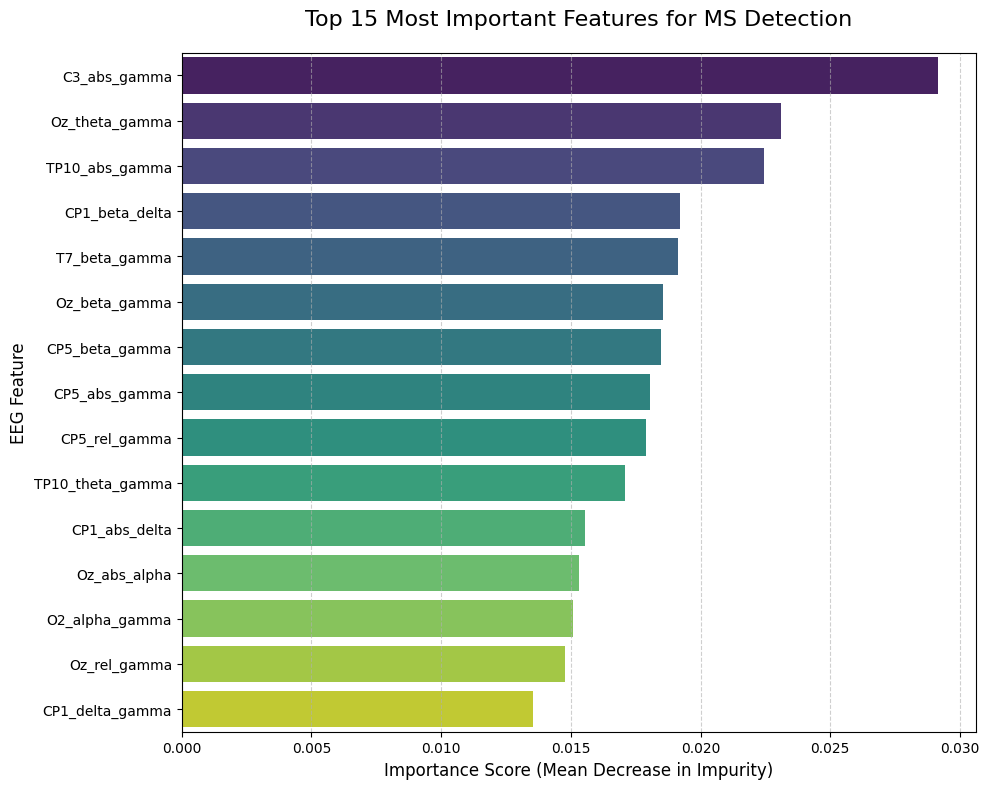


👇 COPY THIS LIST FOR YOUR LDA MODEL 👇
['C3_abs_gamma', 'Oz_theta_gamma', 'TP10_abs_gamma', 'CP1_beta_delta', 'T7_beta_gamma', 'Oz_beta_gamma', 'CP5_beta_gamma', 'CP5_abs_gamma', 'CP5_rel_gamma', 'TP10_theta_gamma']


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# --- STEP 1: Load and Clean Data ---
df = pd.read_csv('FINAL_DATASET_WINDOWED_FULL.csv')

# Drop the broken 'CP2' channel (Artifact Removal)
cols_to_drop = [c for c in df.columns if 'CP2' in c]
df_clean = df.drop(columns=cols_to_drop)

# Define Features (X) and Target (y)
X = df_clean.drop(['Subject_ID', 'Label', 'Window_Index'], axis=1)
y = df_clean['Label']

# --- STEP 2: Train Random Forest to Measure Importance ---
# We don't need to scale data for Random Forest (it handles raw numbers fine)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# --- STEP 3: Extract and Sort Data ---
# Create a neat DataFrame
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

# Sort by importance (High to Low) and grab the Top 15
top_features = feature_importances.sort_values(by='Importance', ascending=False).head(15)

# --- STEP 4: The Visualization Thingy ---
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis', hue='Feature', legend=False)

# Make it look professional
plt.title('Top 15 Most Important Features for MS Detection', fontsize=16, pad=20)
plt.xlabel('Importance Score (Mean Decrease in Impurity)', fontsize=12)
plt.ylabel('EEG Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# --- STEP 5: Print the List for Your LDA Model ---
# This prints the list you need to copy-paste for your next experiment
print("\n👇 COPY THIS LIST FOR YOUR LDA MODEL 👇")
print(top_features['Feature'].head(10).tolist())

## 8. Conclusion and Next Steps

In [ ]:
There are No next steps because this research was aborted.